In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

In [2]:
df=pd.read_csv('dataset/student-lifestyle-and-stress-dataset.csv')

In [3]:
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


Handling The Missing Values

In [4]:
df.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [5]:
df.shape

(25500, 9)

In [6]:
df.dtypes

Student_Type           object
Sleep_Hours           float64
Study_Hours           float64
Social_Media_Hours    float64
Attendance            float64
Exam_Pressure         float64
Family_Support        float64
Month                 float64
Stress_Level            int64
dtype: object

In [7]:
df.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


In [8]:
df['Student_Type'].value_counts()

Student_Type
college            13391
school              6021
working_student     4836
Name: count, dtype: int64

In [9]:
df['Student_Type'].isnull().sum()

np.int64(1252)

In [10]:
df[df["Student_Type"].isna()].head(20)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
21,NaN,4.646379,8.303502,3.019420,98.493938,1.0,4.0,5.0,0
40,NaN,4.907335,6.067431,NaN,83.260939,5.0,4.0,7.0,0
82,NaN,9.150968,1.242483,1.653746,88.102984,6.0,7.0,8.0,0
84,NaN,7.107427,4.141574,1.575881,95.188464,5.0,7.0,NaN,0
87,NaN,3.991247,6.564631,0.947214,86.969110,1.0,9.0,6.0,0
103,NaN,7.522528,4.454901,5.028889,81.421635,5.0,NaN,1.0,0
174,NaN,8.063624,3.787469,0.882453,NaN,2.0,6.0,6.0,0
226,NaN,9.385518,4.588633,4.407257,70.091599,7.0,7.0,4.0,1
251,NaN,8.347053,5.361303,2.712901,85.242179,NaN,10.0,5.0,0
341,NaN,4.651448,8.239760,2.733169,95.897328,5.0,7.0,8.0,1


In [11]:
df["Student_Type"].value_counts(normalize=True, dropna=False)

Student_Type
college            0.525137
school             0.236118
working_student    0.189647
NaN                0.049098
Name: proportion, dtype: float64

In [12]:
#Handling Student_type missing value
#replacing those with mode value 
df["Student_Type"] = df["Student_Type"].fillna("college")

In [13]:
df["Student_Type"].value_counts(normalize=True, dropna=False)

Student_Type
college            0.574235
school             0.236118
working_student    0.189647
Name: proportion, dtype: float64

In [14]:
df.columns

Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='object')

In [15]:
df['Sleep_Hours'].isnull().sum()

np.int64(1333)

In [16]:
#handling sleeping_hours 
df["Sleep_Hours"].skew()

np.float64(-0.23200645724216598)

In [17]:
#the the skew value is close to 0 so we can replace it with mean 
df['Sleep_Hours']=df['Sleep_Hours'].fillna(df['Sleep_Hours'].mean())

In [18]:
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


In [19]:
#Handling the missing values on study hours
df['Study_Hours'].isnull().sum()

np.int64(1277)

In [20]:
df["Study_Hours"].skew()

np.float64(0.5548433521388645)

In [21]:
#though the data is positively skewed over 0.5 so usually i am using median to fill the null values
df['Study_Hours']=df['Study_Hours'].fillna(df['Study_Hours'].median())

In [22]:
#Handling the missing values on Social_Media_Hours
df['Social_Media_Hours'].isnull().sum()

np.int64(1312)

In [23]:
df["Social_Media_Hours"].skew()

np.float64(0.25356734284263316)

In [24]:
#though the data is positively skewed lower than 0.5 so usually i am using mean to fill the null values
df['Social_Media_Hours']=df['Social_Media_Hours'].fillna(df['Social_Media_Hours'].mean())

In [25]:
#Handling missing values in attendence 

df['Attendance'].isnull().sum()

np.int64(1305)

In [26]:
df["Attendance"].skew()

np.float64(-1.1267077935524452)

In [27]:
df['Attendance']=df['Attendance'].fillna(df['Attendance'].median())

In [28]:
#Handing the missing value for Exam_Pressure 
df['Exam_Pressure'].isnull().sum()

np.int64(1270)

In [29]:
df["Exam_Pressure"].skew()

np.float64(0.005089404029236175)

In [30]:
df['Exam_Pressure']=df['Exam_Pressure'].fillna(df['Exam_Pressure'].mean())

In [31]:
#Family_Support	Month	Stress_Level

In [32]:
df['Family_Support'].isnull().sum()

np.int64(1291)

In [33]:
df["Family_Support"].skew()

np.float64(-0.20810318949020373)

In [34]:
df['Family_Support']=df['Family_Support'].fillna(df['Family_Support'].mean())

In [35]:
df['Month'].isnull().sum()

np.int64(1314)

In [36]:
df["Month"].skew()

np.float64(0.005287935477986422)

In [37]:
df['Month']=df['Month'].fillna(df['Month'].mean())

In [38]:
df['Stress_Level'].isnull().sum()

np.int64(0)

In [39]:
df["Stress_Level"].value_counts(normalize=True, dropna=False)

Stress_Level
0    0.700118
1    0.299882
Name: proportion, dtype: float64

train test split

In [40]:
x=df.drop('Stress_Level',axis=1)
y=df['Stress_Level']

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

Using onehot encoding for categorical column student type

In [42]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

train_encoded = ohe.fit_transform(x_train[['Student_Type']])
test_encoded = ohe.transform(x_test[['Student_Type']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Student_Type']),
    index=x_train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Student_Type']),
    index=x_test.index
)

In [43]:
x_train = pd.concat(
    [x_train.drop('Student_Type', axis=1), train_encoded],
    axis=1
)

x_test = pd.concat(
    [x_test.drop('Student_Type', axis=1), test_encoded],
    axis=1
)

In [44]:
x_train.head()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Student_Type_school,Student_Type_working_student
14053,7.622964,5.323090,3.555614,70.765291,8.0,4.0,12.0,0.0,0.0
11448,6.262499,2.152527,1.061452,83.666304,10.0,6.0,3.0,0.0,0.0
16720,5.340578,5.396863,3.886515,78.490895,4.0,6.0,11.0,0.0,1.0
13822,8.752933,2.074922,5.847674,67.878172,7.0,5.0,4.0,1.0,0.0
24220,5.659666,6.186771,2.327852,81.537216,1.0,6.0,9.0,0.0,0.0


Using naive bayas

In [45]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
gnb = GaussianNB() 
model=gnb.fit(x_train,y_train)
y_pred=model.predict(x_test) 
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred)) 
print(recall_score(y_test,y_pred)) 
print(f1_score(y_test,y_pred)) 

0.7896078431372549
0.6825757575757576
0.5794212218649518
0.6267826086956522


Using knn

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
knn = KNeighborsClassifier(n_neighbors=5)
model=knn.fit(x_train,y_train)
y_pred=model.predict(x_test) 
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred)) 
print(recall_score(y_test,y_pred)) 
print(f1_score(y_test,y_pred)) 

0.7845098039215687
0.6932203389830508
0.5260450160771705
0.5981718464351006


using logistic regression

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def make_model(x_train,x_test,y_train,y_test):
    model = LogisticRegression(random_state=0, class_weight='balanced')
    model.fit(x_train, y_train)
    
    # Test predictions
    y_pred = model.predict(x_test)
    
    # Train predictions
    y_pred_train = model.predict(x_train)
    
    print("========== TEST ==========")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    
    print("\n========== TRAIN ==========")
    print("Accuracy :", accuracy_score(y_train, y_pred_train))
    print("Precision:", precision_score(y_train, y_pred_train))
    print("Recall   :", recall_score(y_train, y_pred_train))
    print("F1 Score :", f1_score(y_train, y_pred_train))



In [55]:
#using standard scaler 
from sklearn.preprocessing import StandardScaler 
scale=StandardScaler()
x_train_scale=scale.fit_transform(x_train)
x_test_scale=scale.transform(x_test)
make_model(x_train_scale,x_test_scale,y_train,y_test)

========== TEST ==========
Accuracy : 0.7807843137254902
Precision: 0.6079012345679012
Recall   : 0.7916398713826367
F1 Score : 0.6877094972067039
[[2751  794]
 [ 324 1231]]

========== TRAIN ==========
Accuracy : 0.7847549019607843
Precision: 0.6064588809613218
Recall   : 0.7953053184504267
F1 Score : 0.6881613521766919


In [56]:
def confussion_matrix_plot(cm,i):
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["Not Stressed", "Stressed"],
        yticklabels=["Not Stressed", "Stressed"]
    )
    
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix (Threshold = {i})")
    plt.show()

In [59]:
#ThresHold tuning in Logistic Regression 

def make_model_thresholdAdjust(x_train, x_test, y_train, y_test, threshold):

    model = LogisticRegression(
        random_state=0,
        class_weight='balanced'
    )

    model.fit(x_train, y_train)

    # Probability of positive class
    y_prob_test = model.predict_proba(x_test)[:, 1]
    y_prob_train = model.predict_proba(x_train)[:, 1]
    for i in threshold:
        # Apply custom threshold
        y_pred = (y_prob_test >= i).astype(int)
        y_pred_train = (y_prob_train >= i).astype(int)
    
        print(f"\nThreshold : {i}")
    
        print("\n========== TEST ==========")
        print("Accuracy :", accuracy_score(y_test, y_pred))
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall   :", recall_score(y_test, y_pred))
        print("F1 Score :", f1_score(y_test, y_pred))
        cm=confusion_matrix(y_test,y_pred)
        confussion_matrix_plot(cm,i)
    
        print("\n========== TRAIN ==========")
        print("Accuracy :", accuracy_score(y_train, y_pred_train))
        print("Precision:", precision_score(y_train, y_pred_train))
        print("Recall   :", recall_score(y_train, y_pred_train))
        print("F1 Score :", f1_score(y_train, y_pred_train))


Threshold : 0.3

========== TEST ==========
Accuracy : 0.686078431372549
Precision: 0.4920689655172414
Recall   : 0.917684887459807
F1 Score : 0.640628507295174


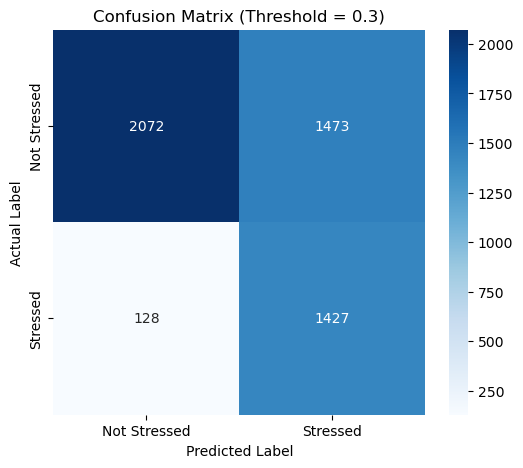


========== TRAIN ==========
Accuracy : 0.6833823529411764
Precision: 0.4839611922034787
Recall   : 0.9088969139855548
F1 Score : 0.631608965949923

Threshold : 0.35

========== TEST ==========
Accuracy : 0.716078431372549
Precision: 0.5200149644594089
Recall   : 0.8938906752411575
F1 Score : 0.6575212866603595


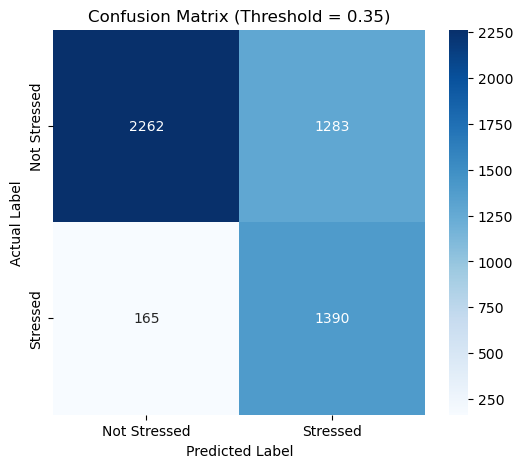


========== TRAIN ==========
Accuracy : 0.715392156862745
Precision: 0.5136164540087602
Recall   : 0.8854235062376887
F1 Score : 0.6501144992165843

Threshold : 0.4

========== TEST ==========
Accuracy : 0.7421568627450981
Precision: 0.5494233937397035
Recall   : 0.8578778135048232
F1 Score : 0.6698468491087121


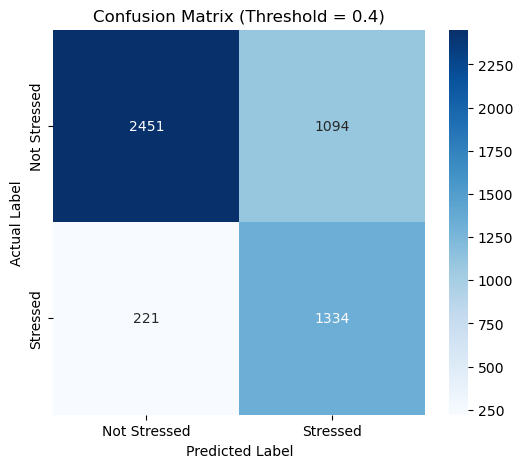


========== TRAIN ==========
Accuracy : 0.7431862745098039
Precision: 0.5444317116366288
Recall   : 0.8578463558765594
F1 Score : 0.6661143330571665

Threshold : 0.45

========== TEST ==========
Accuracy : 0.7605882352941177
Precision: 0.5750224618149147
Recall   : 0.8231511254019293
F1 Score : 0.6770695583179053


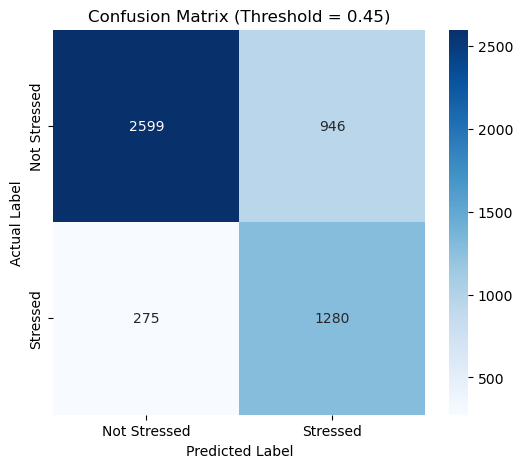


========== TRAIN ==========
Accuracy : 0.7668137254901961
Precision: 0.5761377894376639
Recall   : 0.8291201575837164
F1 Score : 0.6798573255266168

Threshold : 0.5

========== TEST ==========
Accuracy : 0.7807843137254902
Precision: 0.6079012345679012
Recall   : 0.7916398713826367
F1 Score : 0.6877094972067039


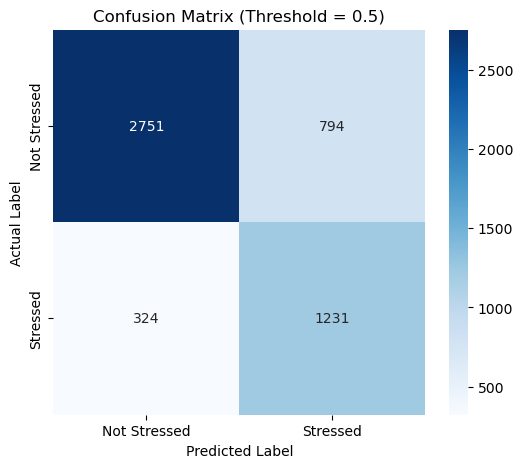


========== TRAIN ==========
Accuracy : 0.7847549019607843
Precision: 0.6064588809613218
Recall   : 0.7953053184504267
F1 Score : 0.6881613521766919


In [60]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]
make_model_thresholdAdjust(x_train_scale,x_test_scale,y_train,y_test,thresholds)

In [49]:
#USING SVM
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def make_SVM_model(x_train,x_test,y_train,y_test):
    model = svm.SVC(kernel='rbf')
    model.fit(x_train, y_train)
    
    # Test predictions
    y_pred = model.predict(x_test)
    
    # Train predictions
    y_pred_train = model.predict(x_train)
    
    print("========== TEST ==========")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    
    print("\n========== TRAIN ==========")
    print("Accuracy :", accuracy_score(y_train, y_pred_train))
    print("Precision:", precision_score(y_train, y_pred_train))
    print("Recall   :", recall_score(y_train, y_pred_train))
    print("F1 Score :", f1_score(y_train, y_pred_train))

In [51]:

make_SVM_model(x_train_scale,x_test_scale,y_train,y_test)


========== TEST ==========
Accuracy : 0.8127450980392157
Precision: 0.7742230347349177
Recall   : 0.5446945337620579
F1 Score : 0.6394865987164968
[[3298  247]
 [ 708  847]]

========== TRAIN ==========
Accuracy : 0.8252450980392156
Precision: 0.7813404586951681
Recall   : 0.5760013131976363
F1 Score : 0.6631389965038269
